# Food Decision Making — Full Eye-Tracking Analysis
## Instructor preparation notebook (private / gitignored)

**Audience:** you only — presentation prep and Q&A readiness.  
**Not for students.** Do not share this file.

**Canonical complete export (confirmed):**  
`C:\Users\snapp\Desktop\Food Decision Making Data Export.tsv`  
→ repo path used here: `Data/food_decision_making/Food Decision Making Data Export.tsv`

---

### What this notebook is for

| Goal | How this notebook helps |
|------|-------------------------|
| Run a complete analysis end-to-end | Sample-level Tobii TSV → TOI → I-VT → AOI → RT → pupil → heatmaps → stats |
| Understand *why* each step exists | Theory cells before every code cell |
| Answer “why this function / argument?” | **Alternatives & Q&A** blocks after key methods |
| Avoid incomplete data silently | Explicit inventory + omit incomplete artifacts |
| Present cleanly | Small tables + one-idea charts saved under `figures/` |

### Pipeline map (say this in one minute)

1. **Inventory** exports → keep complete streams only  
2. **QC recordings** → eligible if gaze quality + all 5 foods  
3. **Clean** timestamps / validity (no harmful imputation)  
4. **TOIs** from ImageStimulusStart/End  
5. **I-VT** fixations/saccades from gaze samples  
6. **AOI metrics** using Tobii AOI hit columns × our fixations  
7. **Behavior** first-click RT + buy/not-buy inference  
8. **Pupil** baseline-corrected within TOI  
9. **Heatmaps / gaze plots** for communication figures  
10. **Stats** participant-level contrasts + simple regression  
11. **Gaps** — what is still missing from Tobii

### How to run

Open this `.ipynb` in Jupyter / VS Code / Cursor and run top → bottom.  
Working directory can be the repo root *or* this private folder — path discovery is automatic.

Required packages: `pandas`, `numpy`, `matplotlib`, `scipy`, `statsmodels`, `Pillow`, `openpyxl` (for XLSX QC).



## 0. Environment, imports, and path discovery

### Theory
Reproducible analysis pins paths to the **repository**, not a personal Desktop path.  
We still treat your Desktop TSV as the *canonical content*; the repo copy must stay in sync with it.

### Libraries used here (and what they are for)

| Library | Role in this notebook | Common alternative |
|---------|----------------------|--------------------|
| `pathlib.Path` | Cross-platform paths | `os.path.join` (older style; more error-prone) |
| `pandas` | Tables, groupby, merges | Polars (faster, different API); base Python (too slow for TSV) |
| `numpy` | Arrays, velocity math | Pure Python loops (fine for teaching tiny demos only) |
| `matplotlib` | Figures | Seaborn (nicer defaults), Plotly (interactive) |
| `scipy.stats` | t-tests, etc. | `pingouin` (APA-friendly), `statsmodels` |
| `statsmodels` | OLS regression | `sklearn.linear_model` (prediction-first, weaker classical summary) |
| `scipy.ndimage.gaussian_filter` | Smooth heatmaps | `skimage`, OpenCV GaussianBlur |
| `PIL.Image` | Load stimulus PNGs | `imageio`, `matplotlib.image.imread` |

### Q&A you may get
- **“Why not Excel for everything?”** Metrics are already aggregated; I-VT and custom RT need sample-level rows.  
- **“Why pathlib?”** `/` vs `\` and accidental double separators break Windows↔Linux teaching machines.  
- **“Why ignore FutureWarning?”** Pandas API churn; warnings distract from the science narrative in live demos.



In [1]:
from __future__ import annotations

import math
import re
import warnings
from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from PIL import Image
from scipy import stats
from scipy.ndimage import gaussian_filter

warnings.filterwarnings("ignore", category=FutureWarning)

# Presentation-friendly defaults (not dense dumps)
pd.set_option("display.max_columns", 22)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 40)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.2),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 120,
})

# Resolve repo root whether kernel cwd is private folder or repo root
HERE = Path.cwd().resolve()
REPO = HERE
for candidate in [HERE, *HERE.parents]:
    if (candidate / "Data" / "food_decision_making").exists():
        REPO = candidate
        break

DATA = REPO / "Data" / "food_decision_making"
LEGACY = REPO / "Data" / "decision making"
STIM = REPO / "Stimuli" / "Decision Making"

# Outputs stay next to this notebook (gitignored private folder)
NOTEBOOK_DIR = REPO / "workshop" / "private_food_decision_analysis"
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = HERE

FIGDIR = NOTEBOOK_DIR / "figures"
TABDIR = NOTEBOOK_DIR / "tables"
FIGDIR.mkdir(parents=True, exist_ok=True)
TABDIR.mkdir(parents=True, exist_ok=True)

print("REPO =", REPO)
print("DATA exists =", DATA.exists(), "→", DATA)
print("STIM exists =", STIM.exists(), "→", STIM)
print("FIGDIR =", FIGDIR)
print("TABDIR =", TABDIR)



REPO = /workspace
DATA exists = True → /workspace/Data/food_decision_making
STIM exists = True → /workspace/Stimuli/Decision Making
FIGDIR = /workspace/workshop/private_food_decision_analysis/figures
TABDIR = /workspace/workshop/private_food_decision_analysis/tables


### Alternatives to the path block above

| Approach | When to use | Trade-off |
|----------|-------------|-----------|
| Hard-code `REPO = Path(r"C:\Users\...")` | Solo laptop demo | Breaks as soon as folder moves |
| Environment variable `EYE_TRACKING_REPO` | Multi-machine workshops | Students forget to set it |
| `pathlib` walk-up (this notebook) | Shared repos / cloud agents | Slightly more code; very robust |
| `%cd` magic in Jupyter | Quick interactive hacking | Hidden state; bad for reproducibility |

**Also:** `pd.set_option("display.max_columns", …)` only affects *display*, not analysis. Alternatives: `df.iloc[:, :10]` for teaching, or `df.info()` for schema.



## 1. Ensure the complete Data Export TSV is available

### Theory — Tobii export families (memorize this)

| Export type | Grain | Can support I-VT? | Can support custom AOI logic? |
|-------------|-------|-------------------|-------------------------------|
| **Data Export** (TSV/XLSX) | One row ≈ one sample / event | **Yes** | **Yes** (AOI hit columns) |
| **Metrics** (TSV/XLSX) | Already aggregated intervals/events | No | Only if AOI field is populated |
| Interval metrics | TOI / media windows | No | Limited |

**Rule:** if a student asks “can we recompute fixations?”, the answer is “only from Data Export (sample-level).”

### Completeness policy
- Prefer the **Desktop TSV** (user-confirmed most complete).  
- Prefer TSV over XLSX for this project because AOI hit columns are richer (`picture`, `name`, `Nutrition`, `price`, `buy`, `not-buy`, …).  
- If the repo TSV is missing, extract from the legacy zip — never invent AOI hits.



In [2]:
TSV_NAME = "Food Decision Making Data Export.tsv"
tsv_path = DATA / TSV_NAME
zip_path = LEGACY / "Food Decision Making Data Export.zip"

if not tsv_path.exists():
    if not zip_path.exists():
        raise FileNotFoundError(
            "Missing complete Data Export TSV and zip.\n"
            "Copy your Desktop file into Data/food_decision_making/:\n"
            r"  C:\Users\snapp\Desktop\Food Decision Making Data Export.tsv"
        )
    with ZipFile(zip_path) as zf:
        # extract only the TSV member (if nested, adjust)
        members = [m for m in zf.namelist() if m.endswith(TSV_NAME) or m == TSV_NAME]
        if not members:
            raise FileNotFoundError(f"{TSV_NAME} not found inside {zip_path}")
        target = members[0]
        DATA.mkdir(parents=True, exist_ok=True)
        with zf.open(target) as src, open(tsv_path, "wb") as dst:
            dst.write(src.read())
    print("Extracted TSV from repo zip →", tsv_path)
else:
    print("Using existing TSV →", tsv_path)

print("size_MB =", round(tsv_path.stat().st_size / 1e6, 2))



Using existing TSV → /workspace/Data/food_decision_making/Food Decision Making Data Export.tsv
size_MB = 11.49


### Alternatives & Q&A — loading the export

| Method | Code shape | When |
|--------|------------|------|
| `pd.read_csv(..., sep="\t")` | This notebook | Tobii TSV |
| `pd.read_excel(..., sheet_name="Data")` | QC / Recording4 check | XLSX Data Export |
| `engine="pyarrow"` / `dtype_backend="pyarrow"` | Huge exports | Faster; needs pyarrow |
| `usecols=[...]` | Memory-tight demos | Faster load; easy to forget a column |
| Chunked `chunksize=` | Multi-GB files | Streaming; harder for TOI joins |

**Q: Why `low_memory=False`?**  
Tobii columns mix types (strings + numbers). With `low_memory=True`, pandas may guess dtypes in chunks and warn / mis-parse.

**Q: Why not convert everything to Parquet first?**  
Great for repeated runs; overkill for a presentation walkthrough of one study export.



## 2. Completeness inventory — omit incomplete artifacts

### Theory
Missingness is scientific information. Imputing AOI labels or GSR when Tobii did not export them creates **false precision**.

Honest workflow:
1. Inventory every candidate table  
2. Mark incomplete (empty sheets, AOI all-NaN, mismatched AOI vocabularies)  
3. Omit those from analyses that require them  
4. Proceed only with complete streams **per analysis family**



In [3]:
inventory = []

def add_inv(name, path, status, detail, use_for):
    inventory.append({
        "artifact": name,
        "path": str(path),
        "status": status,
        "detail": detail,
        "use_for": use_for,
    })

# --- Primary Data Export TSV ---
raw = pd.read_csv(tsv_path, sep="\t", low_memory=False)
aoi_cols_tsv = [c for c in raw.columns if str(c).startswith("AOI hit")]
recs_tsv = sorted(raw["Recording name"].dropna().unique().tolist())
add_inv(
    "Data Export TSV",
    tsv_path,
    "COMPLETE_PRIMARY",
    f"rows={len(raw)}, cols={raw.shape[1]}, recordings={recs_tsv}, n_AOI_hit_cols={len(aoi_cols_tsv)}",
    "sample-level gaze, I-VT, AOI hits, mouse/events, pupil",
)

# --- XLSX Data Export (QC only if AOI scheme differs) ---
xlsx_path = DATA / "Food_Decision_Making_Data_Export.xlsx"
xlsx = pd.read_excel(xlsx_path, sheet_name="Data")
recs_xlsx = sorted(xlsx["Recording name"].dropna().unique().tolist())
aoi_cols_xlsx = [c for c in xlsx.columns if str(c).startswith("AOI hit")]
only_xlsx = sorted(set(recs_xlsx) - set(recs_tsv))
add_inv(
    "Data Export XLSX",
    xlsx_path,
    "PARTIAL",
    f"recordings={recs_xlsx}; AOI cols={len(aoi_cols_xlsx)}; only-in-xlsx={only_xlsx}",
    "QC only for Recording4; NOT merged into rich-AOI pipeline",
)

# --- Metrics TSV ---
metrics_tsv_path = DATA / "Food_Decision_Making_Metrics.tsv"
metrics_tsv = pd.read_csv(metrics_tsv_path, sep="\t")
aoi_null = float(metrics_tsv["AOI"].isna().mean()) if "AOI" in metrics_tsv.columns else 1.0
add_inv(
    "Metrics TSV (event fixations)",
    metrics_tsv_path,
    "PARTIAL" if aoi_null > 0.99 else "COMPLETE",
    f"rows={len(metrics_tsv)}; AOI_null_fraction={aoi_null:.3f}",
    "fixation duration / pupil by Media|TOI only (no AOI labeling)",
)

# --- Metrics XLSX sheets ---
metrics_xlsx_path = DATA / "Food_Decision_Making_Metrics.xlsx"
xl = pd.ExcelFile(metrics_xlsx_path)
complete_sheets, empty_sheets = [], []
for s in xl.sheet_names:
    df_s = pd.read_excel(xl, sheet_name=s, header=None)
    vals = [str(v) for v in df_s.stack(future_stack=True).tolist()[:40]]
    if any("No data available" in v for v in vals) or len(df_s.dropna(how="all")) <= 1:
        empty_sheets.append(s)
    else:
        complete_sheets.append(s)
add_inv(
    "Metrics XLSX",
    metrics_xlsx_path,
    "MOSTLY_INCOMPLETE",
    f"usable_sheets={complete_sheets}; empty_sheets={empty_sheets}",
    "optional interval timing only; omit empty metric sheets",
)

# --- Legacy AOI-based metrics (complete for R1–R3) ---
legacy_aoi_path = LEGACY / "Food Decision Making Metrics (AOI-based).tsv"
legacy_aoi = pd.read_csv(legacy_aoi_path, sep="\t")
add_inv(
    "Legacy AOI-based Metrics TSV",
    legacy_aoi_path,
    "COMPLETE_FOR_R1-R3",
    f"rows={len(legacy_aoi)}; AOIs={sorted(legacy_aoi['AOI'].dropna().unique().tolist())}; "
    f"recordings={sorted(legacy_aoi['Recording'].unique().tolist())}",
    "precomputed AOI dwell/TTFF/visits/clicks; validation tables",
)

inv_df = pd.DataFrame(inventory)
inv_df.to_csv(TABDIR / "inventory.csv", index=False)
inv_df



,artifact,path,status,detail,use_for
0,Data Export TSV,/workspace/Data/food_decision_making/Food Deci...,COMPLETE_PRIMARY,"rows=19737, cols=136, recordings=['Recording1'...","sample-level gaze, I-VT, AOI hits, mouse/event..."
1,Data Export XLSX,/workspace/Data/food_decision_making/Food_Deci...,PARTIAL,"recordings=['Recording1', 'Recording2', 'Recor...",QC only for Recording4; NOT merged into rich-A...
2,Metrics TSV (event fixations),/workspace/Data/food_decision_making/Food_Deci...,PARTIAL,rows=1743; AOI_null_fraction=1.000,fixation duration / pupil by Media|TOI only (n...
3,Metrics XLSX,/workspace/Data/food_decision_making/Food_Deci...,MOSTLY_INCOMPLETE,"usable_sheets=['Interval dur', 'Interval start...",optional interval timing only; omit empty metr...
4,Legacy AOI-based Metrics TSV,/workspace/Data/decision making/Food Decision ...,COMPLETE_FOR_R1-R3,"rows=210; AOIs=['Nutrition', 'buy', 'ingredien...",precomputed AOI dwell/TTFF/visits/clicks; vali...


### Alternatives & Q&A — inventory / completeness

| Policy | Meaning | When students push back |
|--------|---------|-------------------------|
| **Omit incomplete** (this notebook) | No fake AOIs / empty sheets | “But Excel has Recording4!” → different AOI vocabulary; merging would mix apples/oranges |
| Impute AOI as “outside” | Conservative for dwell sums | OK only if you *define* outside as a category |
| Force-merge XLSX+TSV | Maximize N | Dangerous if AOI names differ (`cake-pic` vs `picture`) |
| Analyze Metrics only | Faster labs | Cannot teach I-VT from scratch |

**Q: Why list empty Metrics XLSX sheets instead of deleting the file?**  
So you can tell students/reviewers exactly what Tobii returned vs what you chose to ignore.



## 3. Recording-level QC gate

### Theory
A recording enters the **full AOI pipeline** only if:

1. Enough valid gaze samples (here: ≥ 80% non-null Gaze point X on Eye Tracker rows)  
2. All five food stimuli present: cake, pizza, ice-cream, cereal, date  
3. AOI hit columns exist for that stimulus vocabulary (true for the complete TSV)

Recording4 appears in the XLSX with a *different* AOI naming scheme and is absent from the rich TSV → **omit from the main AOI pipeline**.



In [4]:
FOODS = ["cake", "pizza", "ice-cream", "cereal", "date"]

def recording_qc(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for rec, g in df.groupby("Recording name"):
        eye = g[g["Sensor"] == "Eye Tracker"]
        stims = set(g["Presented Stimulus name"].dropna().astype(str))
        foods_present = sorted(stims.intersection(FOODS))
        gaze_frac = float(eye["Gaze point X"].notna().mean()) if len(eye) else 0.0
        pupil_frac = float(eye["Pupil diameter left"].notna().mean()) if len(eye) else 0.0
        n_clicks = int((g["Event"] == "MouseEvent").sum()) if "Event" in g.columns else 0
        complete = (gaze_frac >= 0.80) and (len(foods_present) == 5)
        rows.append({
            "recording": rec,
            "participant": g["Participant name"].dropna().iloc[0] if g["Participant name"].notna().any() else None,
            "n_eye_samples": int(len(eye)),
            "gaze_valid_frac": round(gaze_frac, 3),
            "pupil_valid_frac": round(pupil_frac, 3),
            "n_mouse_events": n_clicks,
            "foods_present": ", ".join(foods_present),
            "n_foods": len(foods_present),
            "pipeline_eligible": complete,
        })
    return pd.DataFrame(rows).sort_values("recording")

qc = recording_qc(raw)
qc.to_csv(TABDIR / "recording_qc.csv", index=False)
qc



,recording,participant,n_eye_samples,gaze_valid_frac,pupil_valid_frac,n_mouse_events,foods_present,n_foods,pipeline_eligible
0,Recording1,p01,5384,0.931,0.915,16,"cake, cereal, date, ice-cream, pizza",5,True
1,Recording2,P2,6319,0.946,0.895,16,"cake, cereal, date, ice-cream, pizza",5,True
2,Recording3,p03,6536,0.946,0.903,16,"cake, cereal, date, ice-cream, pizza",5,True


In [5]:
eligible = qc.loc[qc["pipeline_eligible"], "recording"].tolist()
omitted = qc.loc[~qc["pipeline_eligible"], "recording"].tolist()
print("ELIGIBLE recordings:", eligible)
print("OMITTED recordings:", omitted)
print("XLSX-only recordings (omitted from rich AOI pipeline):", only_xlsx)

raw_ok = raw[raw["Recording name"].isin(eligible)].copy()
print("Primary analysis rows:", len(raw_ok))



ELIGIBLE recordings: ['Recording1', 'Recording2', 'Recording3']
OMITTED recordings: []
XLSX-only recordings (omitted from rich AOI pipeline): ['Recording4']
Primary analysis rows: 19737


### Alternatives & Q&A — QC thresholds

| Parameter | This notebook | Alternatives | What changes |
|-----------|---------------|--------------|--------------|
| `gaze_frac >= 0.80` | Strict teaching gate | 0.70 / 0.90 | More/fewer recordings |
| Require all 5 foods | Task-complete trials | Allow partial | Unbalanced stimulus N |
| Filter on calibration error columns | Stricter hardware QC | Use Tobii Average calibration accuracy | Needs those columns populated |
| Drop by participant instead of recording | Multi-recording designs | Keep all recordings per person | Changes independence assumptions |

**Q: Is 80% magic?** No — it is a transparent teaching threshold. Publish the value; sensitivity-check if asked.

**Q: Why `Sensor == "Eye Tracker"` before gaze_frac?**  
Mouse rows have no gaze; mixing sensors silently tanks validity fractions.



## 4. Cleaning the sample-level stream (no harmful imputation)

### Theory / principles
- **Do not** interpolate gaze across long gaps for AOI scoring when Tobii already provides AOI hit columns.  
- **EyesNotFound / invalid samples:** exclude from velocity and pupil means.  
- **Timestamps:** this Data Export TSV uses **microseconds** → divide by `1e6`. Some teaching XLSX extracts use milliseconds → always check median Δt.  
- **Sensor column:** Eye Tracker vs Mouse are different samplers — never average them together.

### Cleaning steps
1. Keep eligible recordings only  
2. Detect timestamp unit from median Δt  
3. Build boolean validity for gaze and pupil  
4. Keep participant IDs as clean strings for merges



In [6]:
df = raw_ok.copy()

_ts = pd.to_numeric(df["Recording timestamp"], errors="coerce")
_median_dt = _ts.diff().median()
# Heuristic: ~16667 µs at 60 Hz; ~16.7 ms if already ms
if _median_dt > 1000:
    time_div = 1e6
    time_unit = "microseconds"
else:
    time_div = 1e3
    time_unit = "milliseconds"
print(f"Detected timestamp unit ≈ {time_unit} (median Δt raw = {_median_dt})")

df["time_s"] = _ts / time_div
df["participant"] = df["Participant name"].astype(str).str.strip()

gaze_x = pd.to_numeric(df.get("Gaze point X"), errors="coerce")
gaze_y = pd.to_numeric(df.get("Gaze point Y"), errors="coerce")
df["gaze_x"] = gaze_x
df["gaze_y"] = gaze_y
df["gaze_valid"] = gaze_x.notna() & gaze_y.notna() & (df.get("Eye movement type") != "EyesNotFound")

df["pupil_l"] = pd.to_numeric(df.get("Pupil diameter left"), errors="coerce")
df["pupil_r"] = pd.to_numeric(df.get("Pupil diameter right"), errors="coerce")
df["pupil_mean"] = df[["pupil_l", "pupil_r"]].mean(axis=1, skipna=True)
df["pupil_valid"] = df["pupil_mean"].notna() & df["gaze_valid"]

# Optional: Tobii Validity left/right (often 0=invalid, 1=valid) — show distribution for Q&A
if "Validity left" in df.columns:
    print("Validity left value counts (Eye Tracker):")
    print(df.loc[df["Sensor"] == "Eye Tracker", "Validity left"].value_counts(dropna=False).head())

clean_summary = pd.DataFrame({
    "timestamp_unit": [time_unit],
    "n_rows": [len(df)],
    "n_eye_rows": [int((df["Sensor"] == "Eye Tracker").sum())],
    "gaze_valid_frac_eye": [round(df.loc[df["Sensor"] == "Eye Tracker", "gaze_valid"].mean(), 3)],
    "pupil_valid_frac_eye": [round(df.loc[df["Sensor"] == "Eye Tracker", "pupil_valid"].mean(), 3)],
    "n_mouse_rows": [int((df["Sensor"] == "Mouse").sum())],
    "median_sample_dt_s": [round(df.loc[df["Sensor"] == "Eye Tracker", "time_s"].diff().median(), 4)],
})
clean_summary



Detected timestamp unit ≈ microseconds (median Δt raw = 16665.0)
Validity left value counts (Eye Tracker):
Validity left
Valid      16479
Invalid     1760
Name: count, dtype: int64


,timestamp_unit,n_rows,n_eye_rows,gaze_valid_frac_eye,pupil_valid_frac_eye,n_mouse_rows,median_sample_dt_s
0,microseconds,19737,18239,0.941,0.941,1366,0.0167


### Alternatives & Q&A — cleaning / timestamps / validity

| Choice | This notebook | Alternatives | Risk if wrong |
|--------|---------------|--------------|---------------|
| Time unit auto-detect | median Δt > 1000 → µs | Always `/1e3` or always `/1e6` | TOI durations look like 7000 s or 0.007 s |
| Gaze coords | `Gaze point X/Y` (pixels) | `MCSnorm` (0–1), `DACSmm` | Heatmap misaligned to PNG |
| Pupil | mean(left, right) | left-only; max; PCA | Slight scale differences |
| Invalid handling | drop / boolean mask | linear interpolate short gaps | Interpolation invents gaze inside AOIs |
| `errors="coerce"` | bad strings → NaN | `errors="raise"` | Hard crash on messy exports |

**Classic gotcha (already fixed in this pipeline):** treating µs as ms makes RT/TOI ≈ 7000 “seconds”. Always print `median_sample_dt_s` (expect ~0.008–0.017 at 60–120 Hz).

**Q: Should we use Tobii’s `Eye movement type` instead of our I-VT?**  
Vendor labels are fine for teaching *metrics*; I-VT is for teaching *algorithms*. We compute both and can compare agreement.



## 5. Times of Interest (TOI) from stimulus events

### Theory
A **TOI** is the temporal window when a stimulus is on screen. AOI metrics are only meaningful *inside* the relevant TOI (looking at cake-picture during the pizza trial is a different event).

We reconstruct TOIs from `ImageStimulusStart` / `ImageStimulusEnd` and the `Event value` (stimulus name).

\[
\text{duration}_{TOI} = t_{\text{ImageStimulusEnd}} - t_{\text{ImageStimulusStart}}
\]



In [7]:
events = df.dropna(subset=["Event"]).copy()
starts = events.loc[
    events["Event"] == "ImageStimulusStart",
    ["Recording name", "participant", "time_s", "Event value"],
].rename(columns={"time_s": "onset_s", "Event value": "stimulus", "Recording name": "recording"})

ends = events.loc[
    events["Event"] == "ImageStimulusEnd",
    ["Recording name", "time_s", "Event value"],
].rename(columns={"time_s": "offset_s", "Event value": "stimulus", "Recording name": "recording"})

toi_rows = []
for (rec, stim), sgrp in starts.groupby(["recording", "stimulus"]):
    egrp = ends[(ends["recording"] == rec) & (ends["stimulus"] == stim)].sort_values("offset_s")
    sgrp = sgrp.sort_values("onset_s")
    # Pair in order (assumes one-to-one Start/End sequence per stimulus)
    for (_, srow), (_, erow) in zip(sgrp.iterrows(), egrp.iterrows()):
        if erow["offset_s"] >= srow["onset_s"]:
            toi_rows.append({
                "recording": rec,
                "participant": srow["participant"],
                "stimulus": stim,
                "onset_s": float(srow["onset_s"]),
                "offset_s": float(erow["offset_s"]),
                "duration_s": float(erow["offset_s"] - srow["onset_s"]),
            })

tois = pd.DataFrame(toi_rows)
food_tois = tois[tois["stimulus"].isin(FOODS)].copy()
food_tois.round(3)



,recording,participant,stimulus,onset_s,offset_s,duration_s
0,Recording1,p01,cake,84.594,87.694,3.100
1,Recording1,p01,cereal,63.994,71.694,7.700
2,Recording1,p01,date,78.144,83.977,5.833
8,Recording1,p01,ice-cream,72.027,77.544,5.517
10,Recording1,p01,pizza,56.044,63.361,7.317
12,Recording2,P2,cake,85.530,94.247,8.717
13,Recording2,P2,cereal,66.163,73.030,6.867
14,Recording2,P2,date,96.030,103.330,7.300
20,Recording2,P2,ice-cream,74.713,84.947,10.233
22,Recording2,P2,pizza,58.080,64.230,6.150


,stimulus,N,mean_s,sd_s
0,cake,3,7.044,3.429
1,cereal,3,7.678,0.800
2,date,3,7.472,1.731
3,ice-cream,3,7.206,2.628
4,pizza,3,7.756,1.864


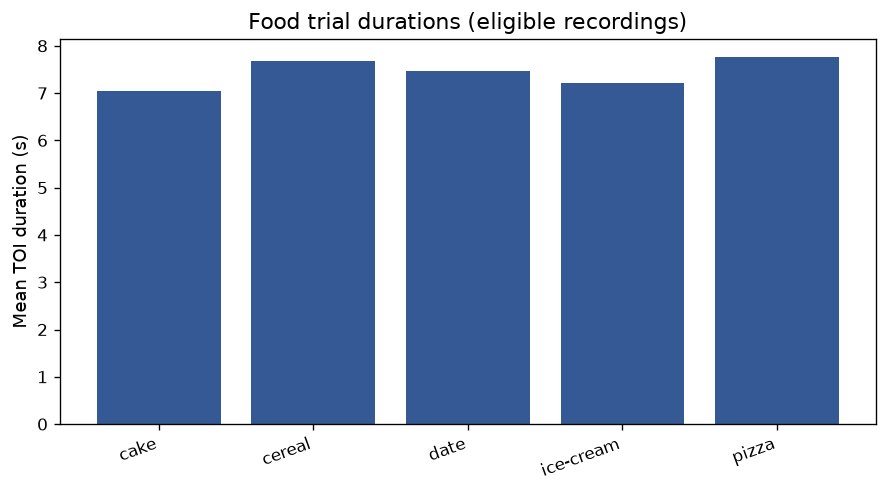

In [8]:
dur_tbl = (
    food_tois.groupby("stimulus", as_index=False)["duration_s"]
    .agg(N="count", mean_s="mean", sd_s="std")
    .round(3)
)
display(dur_tbl)
dur_tbl.to_csv(TABDIR / "food_toi_durations.csv", index=False)

fig, ax = plt.subplots()
ax.bar(dur_tbl["stimulus"], dur_tbl["mean_s"], color="#345995")
ax.set_ylabel("Mean TOI duration (s)")
ax.set_title("Food trial durations (eligible recordings)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(FIGDIR / "toi_durations.png", bbox_inches="tight")
plt.show()



### Alternatives & Q&A — TOI construction

| Method | Idea | Pros / cons |
|--------|------|-------------|
| Event Start/End pairing (here) | Use Tobii events | Exact onsets; fails if unpaired events |
| `Presented Stimulus name` change-points | Infer from media column | Works if events missing; messier edges |
| Tobii Metrics Interval sheets | Vendor TOIs | Easy; empty in this Metrics XLSX |
| Fixed trial duration from design | e.g. always 7 s | Only if experiment was fixed-time |

**Q: Why not use `Recording timestamp` of first gaze on media?**  
Gaze can start after onset (or track during ISI). Events are the ground truth for *presentation*, not attention.

**Q: `zip(starts, ends)` looks fragile — alternatives?**  
Interval-join / `merge_asof` on time within recording; or assign `trial_id` in the stimulus script. For this clean export, ordered pairing works.



## 6. I-VT fixation / saccade classification

### Theory
**I-VT** (Velocity-Threshold Identification; Salvucci & Goldberg, 2000) labels each sample by instantaneous gaze speed:

- low speed → **fixation** sample  
- high speed → **saccade** sample  

Short fixation runs below a minimum duration are discarded (noise / jitter).

**Duration rule (important for exams / Q&A):**  
An event spanning samples \(i \ldots j-1\) lasts from \(t[i]\) until \(t[j]\) (onset of the next different label).  
If the run reaches the last sample, add one median sample step. Using only \(t[j-1] - t[i]\) **under-counts** by ~one sample interval.

### Units
Velocity threshold is in **pixels / second** because `Gaze point X/Y` are pixels here.  
Always verify median Δt first (~0.008–0.017 s after converting timestamps).



In [9]:
def ivt_classify(time_s, x, y, velocity_threshold=5000.0, min_fixation_s=0.06):
    '''Return (samples_df, events_df). Duration ends at next-label onset.

    Parameters
    ----------
    time_s, x, y : array-like
        Seconds and gaze in the same spatial units (here: pixels).
    velocity_threshold : float
        Spatial_units / second. For ~1366x768 media at 60 Hz, try 2000-8000.
    min_fixation_s : float
        Fixation runs shorter than this become unclassified.
    '''
    t = np.asarray(time_s, dtype=float)
    xx = np.asarray(x, dtype=float)
    yy = np.asarray(y, dtype=float)
    dt = np.diff(t)
    step = float(np.nanmedian(dt[dt > 0])) if np.any(dt > 0) else np.nan

    velocity = np.full(len(t), np.nan)
    good = dt > 0
    velocity[1:] = np.where(
        good,
        np.sqrt(np.diff(xx) ** 2 + np.diff(yy) ** 2) / np.where(good, dt, np.nan),
        np.nan,
    )

    label = np.full(len(t), "unclassified", dtype=object)
    ok = np.isfinite(velocity)
    label[ok & (velocity < velocity_threshold)] = "fixation"
    label[ok & (velocity >= velocity_threshold)] = "saccade"
    if len(label) > 1 and label[0] == "unclassified" and label[1] in ("fixation", "saccade"):
        label[0] = label[1]

    # Drop short fixations
    i, n = 0, len(label)
    while i < n:
        if label[i] != "fixation":
            i += 1
            continue
        j = i + 1
        while j < n and label[j] == "fixation":
            j += 1
        end_t = t[j] if j < n else (t[n - 1] + step if np.isfinite(step) else t[n - 1])
        if (end_t - t[i]) < min_fixation_s:
            label[i:j] = "unclassified"
        i = j

    samples = pd.DataFrame({"time_s": t, "x": xx, "y": yy, "velocity": velocity, "label": label})
    change = samples["label"].ne(samples["label"].shift(fill_value=samples["label"].iloc[0]))
    run = change.cumsum()
    rows = []
    for _, g in samples.groupby(run, sort=True):
        lab = g["label"].iloc[0]
        if lab == "unclassified":
            continue
        i0, i1 = int(g.index[0]), int(g.index[-1])
        start = float(t[i0])
        end = float(t[i1 + 1]) if i1 + 1 < n else float(t[i1] + (step if np.isfinite(step) else 0.0))
        rows.append({
            "label": lab,
            "start_s": start,
            "end_s": end,
            "duration_s": end - start,
            "x_mean": float(g["x"].mean()),
            "y_mean": float(g["y"].mean()),
            "n_samples": int(len(g)),
        })
    return samples, pd.DataFrame(rows)


# Run I-VT per recording × food TOI
ivt_events = []
ivt_agree = []
eye = df[(df["Sensor"] == "Eye Tracker") & df["gaze_valid"]].copy()

for _, toi in food_tois.iterrows():
    g = eye[
        (eye["Recording name"] == toi["recording"])
        & (eye["time_s"] >= toi["onset_s"])
        & (eye["time_s"] <= toi["offset_s"])
        & (eye["Presented Stimulus name"] == toi["stimulus"])
    ].sort_values("time_s")
    if len(g) < 5:
        continue
    samples, ev = ivt_classify(g["time_s"], g["gaze_x"], g["gaze_y"])
    ev = ev.copy()
    ev["recording"] = toi["recording"]
    ev["participant"] = toi["participant"]
    ev["stimulus"] = toi["stimulus"]
    ev["toi_onset_s"] = toi["onset_s"]
    ivt_events.append(ev)

    tob = g["Eye movement type"].to_numpy()
    both_mask = np.isin(tob, ["Fixation", "Saccade"])
    if both_mask.any():
        agree = (
            ((tob == "Fixation") & (samples["label"].to_numpy() == "fixation"))
            | ((tob == "Saccade") & (samples["label"].to_numpy() == "saccade"))
        )
        ivt_agree.append({
            "recording": toi["recording"],
            "stimulus": toi["stimulus"],
            "n_compared": int(both_mask.sum()),
            "pct_agree": round(100 * agree[both_mask].mean(), 1),
        })

ivt_events = pd.concat(ivt_events, ignore_index=True) if ivt_events else pd.DataFrame()
ivt_agree = pd.DataFrame(ivt_agree)
fix = ivt_events[ivt_events["label"] == "fixation"].copy()
print("I-VT fixations:", len(fix), "| saccades:", int((ivt_events["label"] == "saccade").sum()))
print("Agreement with Tobii Eye movement type (sample-wise):")
display(ivt_agree.head(10))



I-VT fixations: 448 | saccades: 783
Agreement with Tobii Eye movement type (sample-wise):


,recording,stimulus,n_compared,pct_agree
0,Recording1,cake,171,76.6
1,Recording1,cereal,401,74.3
2,Recording1,date,300,73.3
3,Recording1,ice-cream,276,70.7
4,Recording1,pizza,400,82.8
5,Recording2,cake,460,77.0
6,Recording2,cereal,364,79.1
7,Recording2,date,334,64.7
8,Recording2,ice-cream,562,77.2
9,Recording2,pizza,338,86.7


,stimulus,n_fixations,mean_fix_s,total_dwell_s
0,cake,91,0.166,15.103
1,cereal,93,0.170,15.837
2,date,85,0.136,11.556
3,ice-cream,94,0.163,15.305
4,pizza,85,0.202,17.137


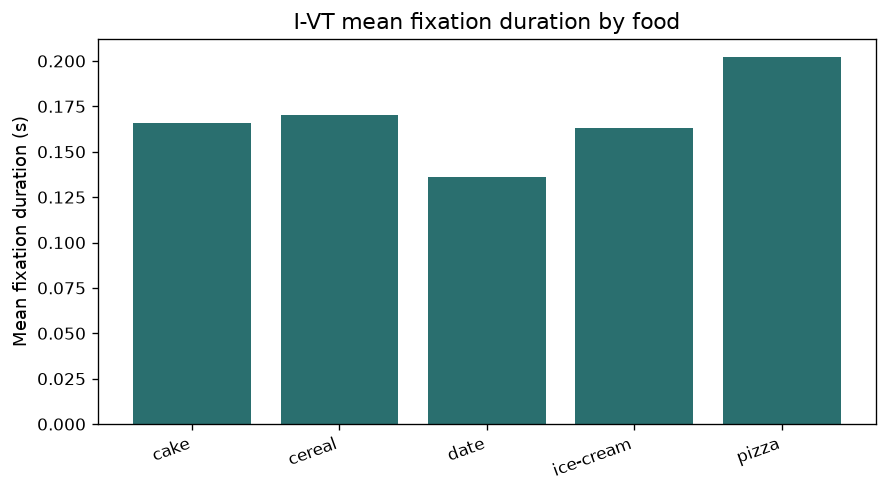

In [10]:
fix_summary = (
    fix.groupby("stimulus", as_index=False)
    .agg(
        n_fixations=("duration_s", "size"),
        mean_fix_s=("duration_s", "mean"),
        total_dwell_s=("duration_s", "sum"),
    )
    .round(3)
)
fix_summary.to_csv(TABDIR / "ivt_fix_summary.csv", index=False)
display(fix_summary)

fig, ax = plt.subplots()
ax.bar(fix_summary["stimulus"], fix_summary["mean_fix_s"], color="#2a6f6f")
ax.set_ylabel("Mean fixation duration (s)")
ax.set_title("I-VT mean fixation duration by food")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(FIGDIR / "ivt_mean_fix_by_food.png", bbox_inches="tight")
plt.show()



### Alternatives & Q&A — fixation classifiers and I-VT arguments

| Algorithm | Core idea | Typical use |
|-----------|-----------|-------------|
| **I-VT** (here) | Velocity threshold | Teaching; online systems |
| **I-DT** | Dispersion (spatial spread) in a window | Noisy / low-Hz data |
| **I-HMM** | Hidden Markov model | Research pipelines |
| Tobii I-VT / Attention Filter | Vendor implementation | Papers matching Pro Lab UI |
| Pupil Labs / Open Gaze | Different defaults | Cross-device comparisons |

#### Argument alternatives for `ivt_classify`

| Argument | Default here | Try instead | Effect |
|----------|--------------|-------------|--------|
| `velocity_threshold` | `5000` px/s | `2000`–`8000` | Lower → more saccades labeled; higher → longer fixations |
| `min_fixation_s` | `0.06` (60 ms) | `0.05`–`0.100` | Higher → fewer micro-fixations counted |
| Gaze units | pixels | degrees of visual angle | Thresholds must be re-tuned (e.g. 30–100 °/s literature range) |
| Velocity definition | point-to-point | Savitzky–Golay smoothed | Less noise; more code |

**Q: Why does agreement with Tobii matter?**  
Shows your implementation is in the same ballpark — not that Tobii is “ground truth.” Filters differ in gap fill, angle conversion, and min duration.

**Q: Why rename loop variable to `ev` not `events`?**  
A classic bug: overwriting the outer `events` DataFrame inside the TOI loop.

**Live demo tip:** pick one TOI, plot velocity vs time, draw a horizontal line at 5000 — students *see* I-VT.



## 7. AOI metrics from Tobii AOI hit columns × I-VT fixations

### Theory — classic AOI metrics

| Metric | Definition used here |
|--------|----------------------|
| **Dwell / total fixation duration** | \(\sum\) fixation durations assigned to AOI |
| **Fixation count** | Number of fixations with that AOI hit |
| **TTFF** | First fixation start in AOI − TOI onset |
| **Visit** | Contiguous run in an AOI (Tobii has a specific visit definition; we mention but do not fully re-implement) |

**Method choice:** assign each I-VT fixation to an AOI by reading Tobii’s AOI hit columns at the nearest eye sample to the fixation start.  
→ Keeps **vendor geometry**, keeps **our timing definition**.



In [11]:
aoi_col_map = {}
for c in aoi_cols_tsv:
    m = re.search(r"AOI hit \[(.+?) - (.+?)\]", c)
    if not m:
        continue
    aoi_col_map[c] = (m.group(1), m.group(2))

print("Parsed AOI columns:", len(aoi_col_map))
print("Unique AOI names:", sorted({a for _, a in aoi_col_map.values()}))

aoi_rows = []
for _, ev in fix.iterrows():
    rec = ev["recording"]
    stim = ev["stimulus"]
    cols = [c for c, (s, a) in aoi_col_map.items() if s == stim]
    if not cols:
        continue
    g = eye[eye["Recording name"] == rec]
    if g.empty:
        continue
    j = (g["time_s"] - ev["start_s"]).abs().idxmin()
    sample = g.loc[j]
    hit_aoi = None
    for c in cols:
        val = sample.get(c)
        try:
            if float(val) == 1.0:
                hit_aoi = aoi_col_map[c][1]
                break
        except Exception:
            continue
    aoi_rows.append({
        "recording": rec,
        "participant": ev["participant"],
        "stimulus": stim,
        "aoi": hit_aoi,
        "duration_s": ev["duration_s"],
        "ttff_s": ev["start_s"] - ev["toi_onset_s"],
        "x_mean": ev["x_mean"],
        "y_mean": ev["y_mean"],
    })

fix_aoi = pd.DataFrame(aoi_rows)
outside_pct = 100 * fix_aoi["aoi"].isna().mean() if len(fix_aoi) else np.nan
print(f"Fixations with no AOI hit: {outside_pct:.1f}% (expected — not all gaze lands in AOIs)")
fix_aoi_hit = fix_aoi.dropna(subset=["aoi"]).copy()
fix_aoi_hit.head(8)



Parsed AOI columns: 35
Unique AOI names: ['Nutrition', 'buy', 'ingredients', 'name', 'not-buy', 'picture', 'price']


Fixations with no AOI hit: 49.3% (expected — not all gaze lands in AOIs)


,recording,participant,stimulus,aoi,duration_s,ttff_s,x_mean,y_mean
0,Recording1,p01,cake,picture,0.166463,0.119066,933.400000,393.400000
3,Recording1,p01,cake,name,0.183308,0.752288,1100.909091,185.090909
4,Recording1,p01,cake,name,0.066656,0.952255,1095.000000,193.750000
6,Recording1,p01,cake,picture,0.133331,1.302391,1183.000000,645.750000
7,Recording1,p01,cake,name,0.133297,1.669057,982.375000,195.375000
8,Recording1,p01,cake,name,0.166718,1.852365,1109.600000,191.100000
9,Recording1,p01,cake,name,0.200060,2.035752,1023.083333,231.250000
10,Recording1,p01,cake,buy,0.066663,2.285652,1245.750000,919.250000


In [12]:
aoi_metrics = (
    fix_aoi_hit.groupby(["stimulus", "aoi"], as_index=False)
    .agg(
        n_fixations=("duration_s", "size"),
        dwell_s=("duration_s", "sum"),
        mean_fix_s=("duration_s", "mean"),
        median_TTFF_s=("ttff_s", "median"),
    )
    .round(3)
)

aoi_by_pp = (
    fix_aoi_hit.groupby(["participant", "stimulus", "aoi"], as_index=False)
    .agg(
        dwell_s=("duration_s", "sum"),
        n_fixations=("duration_s", "size"),
        TTFF_s=("ttff_s", "min"),
    )
)

pivot = (
    aoi_metrics.pivot_table(index="aoi", columns="stimulus", values="dwell_s", aggfunc="sum")
    .fillna(0)
    .round(2)
)
pivot.to_csv(TABDIR / "aoi_dwell_pivot.csv")
pivot



stimulus,cake,cereal,date,ice-cream,pizza
aoi,,,,,
Nutrition,1.18,2.47,2.75,0.35,1.10
buy,0.45,0.42,0.08,0.48,1.58
ingredients,0.28,0.47,0.68,0.77,0.43
name,3.55,0.72,1.62,2.12,1.03
not-buy,0.00,0.17,0.00,0.00,0.57
picture,3.18,2.32,1.30,2.78,2.40
price,0.00,0.22,0.38,0.25,0.13


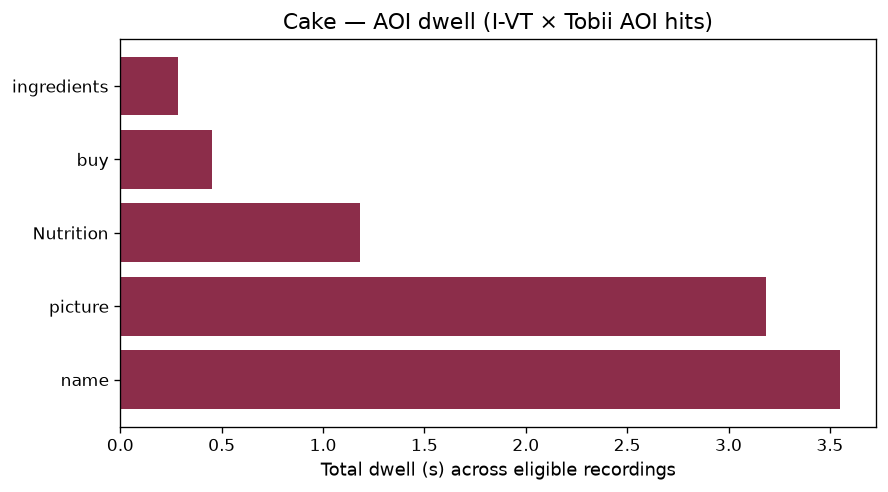

,stimulus,aoi,n_fixations,dwell_s,mean_fix_s,median_TTFF_s
3,cake,name,18,3.550,0.197,2.312
4,cake,picture,21,3.183,0.152,3.770
0,cake,Nutrition,8,1.183,0.148,4.982
1,cake,buy,5,0.450,0.090,2.469
2,cake,ingredients,3,0.283,0.094,7.716


In [13]:
cake_aoi = aoi_metrics[aoi_metrics["stimulus"] == "cake"].sort_values("dwell_s", ascending=False)
fig, ax = plt.subplots()
ax.barh(cake_aoi["aoi"], cake_aoi["dwell_s"], color="#8c2d4a")
ax.set_xlabel("Total dwell (s) across eligible recordings")
ax.set_title("Cake — AOI dwell (I-VT × Tobii AOI hits)")
plt.tight_layout()
fig.savefig(FIGDIR / "cake_aoi_dwell.png", bbox_inches="tight")
plt.show()
cake_aoi



### Alternatives & Q&A — AOI assignment

| Approach | Description | Trade-off |
|----------|-------------|-----------|
| Tobii AOI hit @ nearest sample (here) | Use vendor polygons | Depends on export including AOI hits |
| Point-in-polygon on fixation centroid | Your own AOI shapes | Full control; need coordinates |
| Sample-level dwell (sum dt while hit=1) | No fixation filter | Includes smooth pursuit / jitter as “dwell” |
| Vendor Metrics AOI tables | Pro Lab definitions | Empty AOI column in this Metrics TSV |
| Soft / probabilistic AOIs | Distance kernels | Advanced; rare in undergrad labs |

**TTFF alternatives:** min fixation start in AOI (here); first sample hit; Tobii “Time to first fixation” metric.  
**Missing TTFF:** if AOI never fixated → leave as NaN (do **not** code as trial duration).

**Q: Overlapping AOIs?**  
Tobii can hit multiple; this code takes the first matching column. Alternatives: priority order, or allow multi-label and split duration.



## 8. Behavior: mouse clicks, RT, and purchase decisions

### Theory
Decision time ≠ total dwell. A principled RT:

\[
RT = t_{\text{first click inside TOI}} - t_{\text{stimulus onset}}
\]

If no click occurs in the window, RT is **missing** (`NaN`), not zero.

Purchase outcome inference options:
1. AOI hit on `buy` / `not-buy` near click time (used here)  
2. Mouse coordinates vs button rectangles  
3. Legacy metrics `purchase_decision` when exported



In [14]:
clicks = events.loc[
    events["Event"] == "MouseEvent",
    ["Recording name", "participant", "time_s", "Event value"],
].rename(columns={"Recording name": "recording"})

rt_rows = []
for _, toi in food_tois.iterrows():
    c = clicks[
        (clicks["recording"] == toi["recording"])
        & (clicks["time_s"] >= toi["onset_s"])
        & (clicks["time_s"] <= toi["offset_s"])
    ]
    if len(c) == 0:
        rt_rows.append({
            "recording": toi["recording"],
            "participant": toi["participant"],
            "stimulus": toi["stimulus"],
            "RT_s": np.nan,
            "n_clicks": 0,
            "first_click_value": None,
            "choice_from_aoi_at_click": None,
        })
        continue
    first = c.sort_values("time_s").iloc[0]
    choice = None
    near = df[df["Recording name"] == toi["recording"]]
    j = (near["time_s"] - first["time_s"]).abs().idxmin()
    sample = near.loc[j]
    for cname, (stim, aoi) in aoi_col_map.items():
        if stim != toi["stimulus"]:
            continue
        if aoi in ("buy", "not-buy"):
            try:
                if float(sample.get(cname, 0)) == 1.0:
                    choice = aoi
                    break
            except Exception:
                pass
    rt_rows.append({
        "recording": toi["recording"],
        "participant": toi["participant"],
        "stimulus": toi["stimulus"],
        "RT_s": float(first["time_s"] - toi["onset_s"]),
        "n_clicks": int(len(c)),
        "first_click_value": first["Event value"],
        "choice_from_aoi_at_click": choice,
    })

rt = pd.DataFrame(rt_rows)
rt["RT_s"] = rt["RT_s"].round(3)
rt



,recording,participant,stimulus,RT_s,n_clicks,first_click_value,choice_from_aoi_at_click
0,Recording1,p01,cake,3.067,1,"Down, Left",NaN
1,Recording1,p01,cereal,7.670,1,"Down, Left",NaN
2,Recording1,p01,date,5.795,1,"Down, Left",buy
3,Recording1,p01,ice-cream,5.486,1,"Down, Left",NaN
4,Recording1,p01,pizza,7.277,1,"Down, Left",NaN
5,Recording2,P2,cake,8.689,1,"Down, Left",NaN
6,Recording2,P2,cereal,6.832,1,"Down, Left",NaN
7,Recording2,P2,date,7.268,1,"Down, Left",NaN
8,Recording2,P2,ice-cream,10.192,1,"Down, Left",NaN
9,Recording2,P2,pizza,6.115,1,"Down, Left",not-buy


,stimulus,N,mean_RT_s,sd_RT_s
0,cake,3,7.013,3.430
1,cereal,3,7.643,0.797
2,date,3,7.438,1.734
3,ice-cream,3,7.173,2.621
4,pizza,3,7.721,1.867


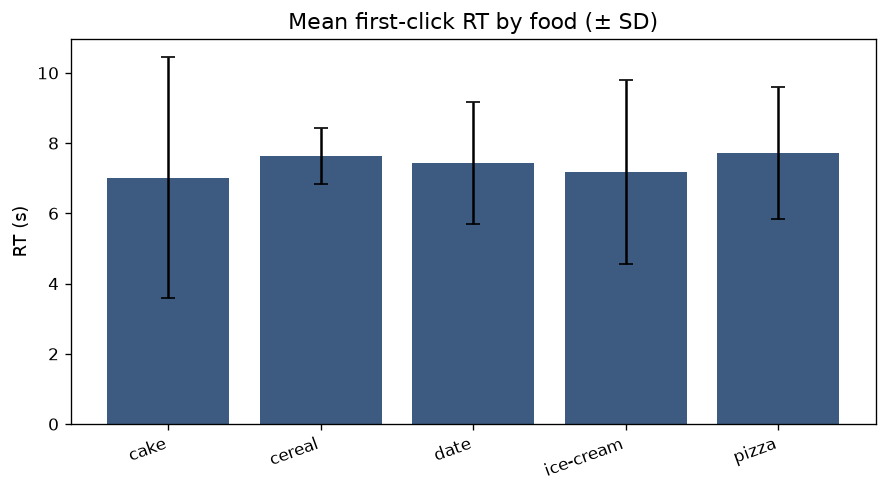

Choice counts:
choice_from_aoi_at_click
NaN        12
not-buy     2
buy         1
Name: count, dtype: int64


In [15]:
rt_summary = (
    rt.dropna(subset=["RT_s"])
    .groupby("stimulus", as_index=False)["RT_s"]
    .agg(N="count", mean_RT_s="mean", sd_RT_s="std")
    .round(3)
)
rt_summary.to_csv(TABDIR / "rt_summary.csv", index=False)
display(rt_summary)

fig, ax = plt.subplots()
ax.bar(
    rt_summary["stimulus"],
    rt_summary["mean_RT_s"],
    yerr=rt_summary["sd_RT_s"],
    capsize=4,
    color="#3d5a80",
)
ax.set_ylabel("RT (s)")
ax.set_title("Mean first-click RT by food (± SD)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(FIGDIR / "rt_by_food.png", bbox_inches="tight")
plt.show()

print("Choice counts:")
print(rt["choice_from_aoi_at_click"].value_counts(dropna=False))



### Alternatives & Q&A — RT and choice

| RT definition | Formula | Notes |
|---------------|---------|-------|
| First click in TOI (here) | \(t_{click1} - t_{onset}\) | Standard decision-time teaching definition |
| Last click in TOI | final commitment | If people click then correct |
| Mouse-down vs Mouse-up | Event value dependent | Check what Tobii stores in MouseEvent |
| Button-AOI entry time | gaze reaches buy AOI | Not a motor RT |
| Timeout → max duration | code missing as trial length | **Biases** mean RT downward/upward — avoid unless survival analysis |

**Q: Why NaN not 0 for no-click?**  
Zero would mean “instant decision.” Missing means “no observed response.”

**Q: Alternatives to AOI-at-click for choice?**  
`Mouse position X/Y` vs hardcoded button boxes; or export a logged response variable from the stimulus script.



## 9. Pupil analysis (baseline-corrected within TOI)

### Theory
Pupil diameter indexes arousal / cognitive load but is **confounded by** luminance, blinks, accommodation, drugs, and age.

Teaching baseline used here: mean pupil in the first **0.5 s** of each food TOI:

\[
pupil_{\text{corr}}(t) = pupil(t) - baseline_{TOI}
\]

Invalid samples are **omitted** (not interpolated) for mean summaries.



In [16]:
pupil_rows = []
BASELINE_S = 0.5  # alternative values discussed in markdown below

for _, toi in food_tois.iterrows():
    g = df[
        (df["Recording name"] == toi["recording"])
        & (df["Sensor"] == "Eye Tracker")
        & (df["pupil_valid"])
        & (df["time_s"] >= toi["onset_s"])
        & (df["time_s"] <= toi["offset_s"])
    ].sort_values("time_s")
    if len(g) < 10:
        continue
    base = g.loc[g["time_s"] <= toi["onset_s"] + BASELINE_S, "pupil_mean"].mean()
    pupil_rows.append({
        "recording": toi["recording"],
        "participant": toi["participant"],
        "stimulus": toi["stimulus"],
        "baseline": base,
        "mean_pupil": g["pupil_mean"].mean(),
        "mean_pupil_corr": (g["pupil_mean"] - base).mean(),
        "n": len(g),
    })

pupil_tbl = pd.DataFrame(pupil_rows).round(3)
pupil_by_stim = (
    pupil_tbl.groupby("stimulus", as_index=False)["mean_pupil_corr"]
    .agg(N="count", mean="mean", sd="std")
    .round(3)
)
pupil_by_stim.to_csv(TABDIR / "pupil_by_stim.csv", index=False)
pupil_by_stim



,stimulus,N,mean,sd
0,cake,3,-0.071,0.049
1,cereal,3,-0.048,0.124
2,date,3,-0.072,0.086
3,ice-cream,3,-0.053,0.082
4,pizza,3,0.128,0.072


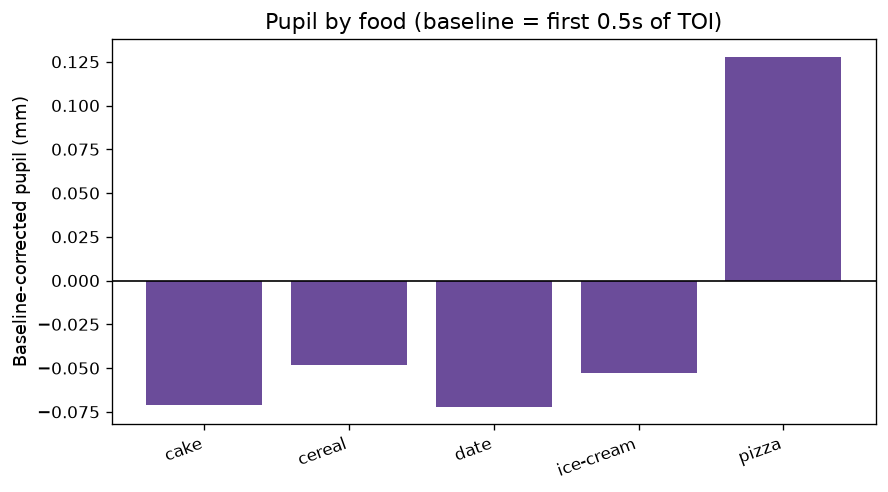

In [17]:
fig, ax = plt.subplots()
ax.bar(pupil_by_stim["stimulus"], pupil_by_stim["mean"], color="#6b4c9a")
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("Baseline-corrected pupil (mm)")
ax.set_title(f"Pupil by food (baseline = first {BASELINE_S}s of TOI)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(FIGDIR / "pupil_by_food.png", bbox_inches="tight")
plt.show()



### Alternatives & Q&A — pupil

| Choice | This notebook | Alternatives |
|--------|---------------|--------------|
| Baseline window | 0.5 s post-onset | −0.5…0 pre-stimulus; 1.0 s; z-score within recording |
| Combine eyes | mean(L,R) | left only; max; discard if \|L−R\| large |
| Blink handling | drop invalid | interpolate ≤150 ms gaps (common in pupillometry) |
| Divisive vs subtractive baseline | subtractive | percent change \((x-b)/b\) |
| Link to luminance | not modeled | include pixel mean of stimulus as covariate |

**Q: Can we claim “cognitive load” from pupil alone?**  
Not cleanly in a bright packaged-food display — luminance differs by stimulus art. Say “pupil (load/arousal proxy, luminance-confounded).”



## 10. Heatmaps and Tobii-style gaze plots

### Theory
| Figure | What it shows |
|--------|----------------|
| **Count heatmap** | Where fixations land (ignores duration) |
| **Duration heatmap** | Attention time (weighted by fixation duration) |
| **Gaze plot** | Ordered fixations; circle size ∝ duration |

These are **descriptive** visualizations, not inferential tests.



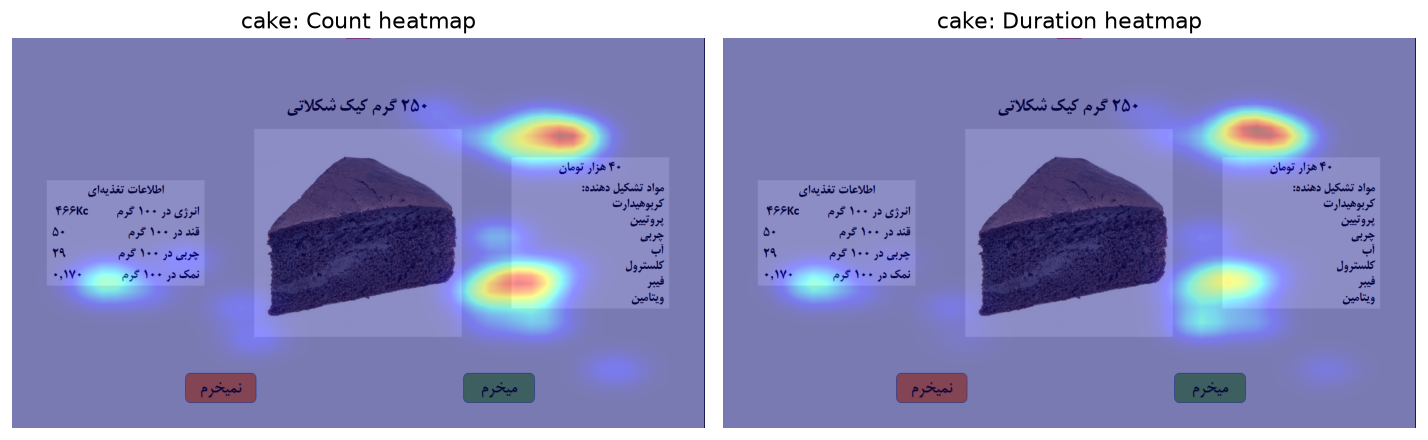

In [18]:
stim = "cake"  # change to pizza / cereal / ... for other slides
stim_path = STIM / f"{stim}.png"
if not stim_path.exists():
    raise FileNotFoundError(stim_path)

img = np.asarray(Image.open(stim_path).convert("RGBA"))
h, w = img.shape[:2]

fix_stim = fix_aoi_hit[fix_aoi_hit["stimulus"] == stim].copy()
xs = fix_stim["x_mean"].to_numpy()
ys = fix_stim["y_mean"].to_numpy()
durs = fix_stim["duration_s"].to_numpy()

BINS = 50          # alternatives: 30 (coarser), 80 (finer)
SIGMA = 1.5        # alternatives: 1.0–3.0
CMAP = "jet"       # alternatives: "hot", "inferno", "viridis" (viridis is colorblind-safer)

def heat(weights=None):
    H, _, _ = np.histogram2d(xs, ys, bins=BINS, range=[[0, w], [0, h]], weights=weights)
    return gaussian_filter(H.T.astype(float), sigma=SIGMA)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, weights, title in [(axes[0], None, "Count heatmap"), (axes[1], durs, "Duration heatmap")]:
    ax.imshow(img)
    ax.imshow(heat(weights), extent=[0, w, h, 0], alpha=0.45, cmap=CMAP, interpolation="bilinear")
    ax.set_title(f"{stim}: {title}")
    ax.axis("off")
plt.tight_layout()
fig.savefig(FIGDIR / f"{stim}_heatmaps.png", bbox_inches="tight")
plt.show()



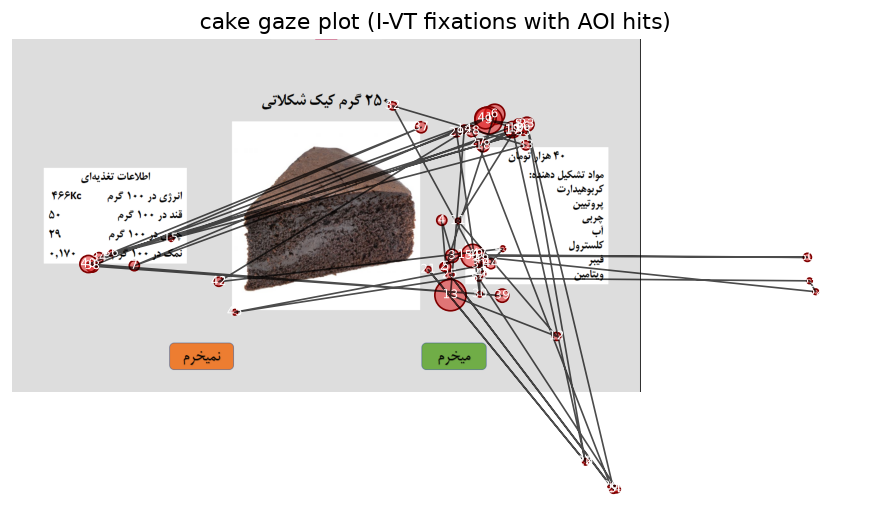

,duration_s,aoi,ttff_s
286,0.066685,picture,0.000047
130,0.116664,picture,0.015720
287,0.216752,picture,0.100079
0,0.166463,picture,0.119066
131,0.166564,picture,0.165715
133,0.333603,name,0.565506
289,0.166058,Nutrition,0.633104
3,0.183308,name,0.752288
290,0.449979,name,0.882607
4,0.066656,name,0.952255


In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.imshow(img)
fx = fix_stim.sort_values("ttff_s")
ax.plot(fx["x_mean"], fx["y_mean"], color="black", lw=1, alpha=0.7)
max_r = 34
scale = max_r / max(fx["duration_s"].max(), 1e-6)
for i, (_, r) in enumerate(fx.iterrows(), start=1):
    rad = max(6, r["duration_s"] * scale)
    ax.add_patch(Circle((r["x_mean"], r["y_mean"]), rad, facecolor="#e41a1c88", edgecolor="#7f0000"))
    ax.text(r["x_mean"], r["y_mean"], str(i), color="white", ha="center", va="center", fontsize=7)
ax.set_title(f"{stim} gaze plot (I-VT fixations with AOI hits)")
ax.axis("off")
plt.tight_layout()
fig.savefig(FIGDIR / f"{stim}_gazeplot.png", bbox_inches="tight")
plt.show()
fx[["duration_s", "aoi", "ttff_s"]].head(12)



### Alternatives & Q&A — visualization knobs

| Knob | Here | Alternatives | Effect |
|------|------|--------------|--------|
| `bins` | 50 | 30 / 80 | Smooth vs sharp hotspots |
| `sigma` | 1.5 | 0 (raw) / 3 | Gaussian blur amount |
| `cmap` | `jet` (Tobii-like) | `viridis`, `magma` | Colorblind accessibility |
| Weights | None vs duration | log(duration) | Compress long fixations |
| Gaze plot order | `ttff_s` | absolute time | Sequence within TOI |
| Pooling | all eligible recordings | one participant | Group vs individual story |

**Q: Why can heatmap disagree with AOI bar chart?**  
Heatmaps use spatial bins; AOI charts use named regions. Gaze just outside an AOI still colors the heatmap.



## 11. Legacy Tobii AOI metrics (validation view for Recording1–3)

### Theory
Vendor metrics are useful **when complete** because AOI geometry and visit definitions match Tobii Pro Lab.  
We use them as a second view / validation and omit empty Metric-XLSX sheets.



In [20]:
legacy = legacy_aoi.copy()
legacy_food = legacy[legacy["TOI"].isin(FOODS)].copy()
for c in [
    "Total_duration_of_fixations",
    "Number_of_fixations",
    "Time_to_first_fixation",
    "Number_of_mouse_clicks",
    "Time_to_first_mouse_click",
    "Average_pupil_diameter",
]:
    if c in legacy_food.columns:
        legacy_food[c] = pd.to_numeric(legacy_food[c], errors="coerce")

legacy_dwell = (
    legacy_food.groupby("AOI", as_index=False)["Total_duration_of_fixations"]
    .agg(N="count", mean_dwell="mean", sd="std")
    .round(1)
    .sort_values("mean_dwell", ascending=False)
)
legacy_dwell.to_csv(TABDIR / "legacy_aoi_dwell.csv", index=False)
legacy_dwell



,AOI,N,mean_dwell,sd
5,picture,15,1285.9,705.9
3,name,15,946.9,490.0
0,Nutrition,15,806.2,628.7
2,ingredients,15,347.8,313.3
1,buy,15,253.1,234.0
6,price,15,98.9,125.4
4,not-buy,15,71.7,164.4


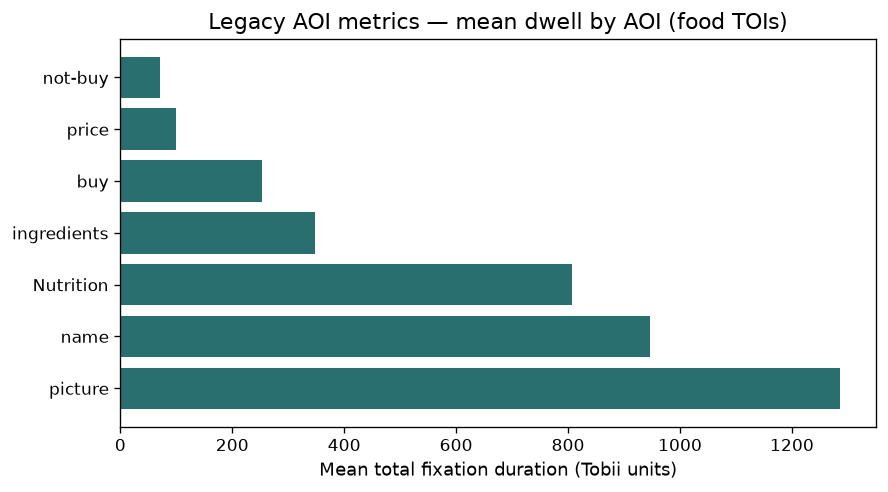

In [21]:
fig, ax = plt.subplots()
ax.barh(legacy_dwell["AOI"], legacy_dwell["mean_dwell"], color="#2a6f6f")
ax.set_xlabel("Mean total fixation duration (Tobii units)")
ax.set_title("Legacy AOI metrics — mean dwell by AOI (food TOIs)")
plt.tight_layout()
fig.savefig(FIGDIR / "legacy_aoi_dwell.png", bbox_inches="tight")
plt.show()



### Alternatives & Q&A — vendor vs custom metrics

| Source | Use when | Caution |
|--------|----------|---------|
| Legacy AOI Metrics TSV | Matching Pro Lab slides | Units may be ms — check headers |
| Our I-VT × AOI hits | Teaching algorithm + geometry | May differ numerically from Tobii |
| Metrics XLSX | Only non-empty sheets | Most sheets empty here → omit |

**Q: Why don’t numbers match Tobii UI exactly?**  
Different fixation filter, visit definition, whether “Entire Recording” is included, and whether AOI hits use binocular vs left/right.



## 12. Statistical models (participant-level)

### Theory
Inferential claims need an independent unit of analysis.  
Here: **participant × stimulus** dwell on focal AOIs (`picture` vs `Nutrition`), plus a simple RT regression.

We report Mean (SD), a paired contrast with effect size, and one OLS model — academic style, still teachable live.



In [22]:
pic = aoi_by_pp[aoi_by_pp["aoi"] == "picture"][["participant", "stimulus", "dwell_s"]].rename(
    columns={"dwell_s": "dwell_picture"}
)
nut = aoi_by_pp[aoi_by_pp["aoi"] == "Nutrition"][["participant", "stimulus", "dwell_s"]].rename(
    columns={"dwell_s": "dwell_nutrition"}
)
paired = pic.merge(nut, on=["participant", "stimulus"], how="inner")

desc = pd.DataFrame([
    {"measure": "picture dwell (s)", "N": len(paired),
     "Mean": paired["dwell_picture"].mean(), "SD": paired["dwell_picture"].std(ddof=1)},
    {"measure": "Nutrition dwell (s)", "N": len(paired),
     "Mean": paired["dwell_nutrition"].mean(), "SD": paired["dwell_nutrition"].std(ddof=1)},
]).round(3)
display(desc)

if len(paired) >= 3:
    diff = paired["dwell_picture"] - paired["dwell_nutrition"]
    t_res = stats.ttest_rel(paired["dwell_picture"], paired["dwell_nutrition"])
    d_z = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else np.nan
    p = float(t_res.pvalue)
    p_txt = "< .001" if p < 0.001 else f"= {p:.3f}".replace("0.", ".")
    apa = f"Paired t-test: t({len(diff)-1}) = {t_res.statistic:.2f}, p {p_txt}, dz = {d_z:.2f}"
    print(apa)
else:
    print("Not enough paired observations for t-test.")

paired.head()



,measure,N,Mean,SD
0,picture dwell (s),14,0.834,0.448
1,Nutrition dwell (s),14,0.561,0.451


Paired t-test: t(13) = 1.41, p = .181, dz = 0.38


,participant,stimulus,dwell_picture,dwell_nutrition
0,P2,cake,1.099756,0.933457
1,P2,cereal,0.500027,0.466107
2,P2,date,0.566637,0.466707
3,P2,ice-cream,1.633210,0.066654
4,P2,pizza,0.683426,0.616683


In [23]:
# Also show Welch *independent* t-test as an alternative contrast style (unequal n / variance)
# Example: RT for trials with choice==buy vs choice==not-buy (if both exist)
buy_rt = rt.loc[rt["choice_from_aoi_at_click"] == "buy", "RT_s"].dropna()
not_rt = rt.loc[rt["choice_from_aoi_at_click"] == "not-buy", "RT_s"].dropna()
if len(buy_rt) >= 2 and len(not_rt) >= 2:
    w = stats.ttest_ind(buy_rt, not_rt, equal_var=False)
    # Cohen's d (Welch-friendly pooled approx)
    s1, s2 = buy_rt.std(ddof=1), not_rt.std(ddof=1)
    sp = np.sqrt((s1**2 + s2**2) / 2)
    d = (buy_rt.mean() - not_rt.mean()) / sp if sp > 0 else np.nan
    print(f"Welch t (buy vs not-buy RT): t ≈ {w.statistic:.2f}, p = {w.pvalue:.3f}, d ≈ {d:.2f}")
    print(f"N_buy={len(buy_rt)}, N_not={len(not_rt)}")
else:
    print("Not enough buy/not-buy RTs for Welch example.")



Not enough buy/not-buy RTs for Welch example.


In [24]:
import statsmodels.formula.api as smf

reg_df = rt.merge(
    aoi_by_pp[aoi_by_pp["aoi"] == "picture"][["participant", "stimulus", "dwell_s"]].rename(
        columns={"dwell_s": "dwell_picture"}
    ),
    on=["participant", "stimulus"],
    how="left",
).merge(
    aoi_by_pp[aoi_by_pp["aoi"] == "Nutrition"][["participant", "stimulus", "dwell_s"]].rename(
        columns={"dwell_s": "dwell_nutrition"}
    ),
    on=["participant", "stimulus"],
    how="left",
)
reg_df = reg_df.dropna(subset=["RT_s"]).fillna({"dwell_picture": 0.0, "dwell_nutrition": 0.0})

if len(reg_df) >= 6:
    fit = smf.ols("RT_s ~ dwell_picture + dwell_nutrition", data=reg_df).fit()
    coef = fit.summary2().tables[1][["Coef.", "Std.Err.", "t", "P>|t|"]].round(3)
    display(coef)
    display(pd.DataFrame([{"N": int(fit.nobs), "R2": round(fit.rsquared, 3), "Adj_R2": round(fit.rsquared_adj, 3)}]))
else:
    print("Not enough trials with RT for regression.")

reg_df[["stimulus", "RT_s", "dwell_picture", "dwell_nutrition", "choice_from_aoi_at_click"]].head(10)



,Coef.,Std.Err.,t,P>|t|
Intercept,3.783,0.804,4.707,0.001
dwell_picture,3.227,0.723,4.461,0.001
dwell_nutrition,1.979,0.715,2.766,0.017


,N,R2,Adj_R2
0,15,0.667,0.611


,stimulus,RT_s,dwell_picture,dwell_nutrition,choice_from_aoi_at_click
0,cake,3.067,0.299794,0.000000,NaN
1,cereal,7.670,0.649933,0.966640,NaN
2,date,5.795,0.333347,0.632752,buy
3,ice-cream,5.486,0.766492,0.116892,NaN
4,pizza,7.277,0.849947,0.233330,NaN
5,cake,8.689,1.099756,0.933457,NaN
6,cereal,6.832,0.500027,0.466107,NaN
7,date,7.268,0.566637,0.466707,NaN
8,ice-cream,10.192,1.633210,0.066654,NaN
9,pizza,6.115,0.683426,0.616683,not-buy


### Alternatives & Q&A — statistics

| Analysis | Function / approach | When to prefer |
|----------|---------------------|----------------|
| Paired t-test | `scipy.stats.ttest_rel` | Same participant, two AOIs |
| Welch t-test | `ttest_ind(..., equal_var=False)` | Unequal n or variance; default teaching choice over Student’s t |
| Student’s t | `equal_var=True` | Only if variances clearly similar |
| Wilcoxon / Mann–Whitney | `wilcoxon`, `mannwhitneyu` | Skewed RT; small N |
| OLS | `statsmodels.formula.api.ols` | Continuous predictors; classic tables |
| Mixed effects | `mixedlm` / `lmer` via R | Multiple trials nested in participants (**better** for real papers) |
| ANOVA / LMM on AOI | formula with AOI factor | Multi-AOI designs |
| `pingouin` | `pg.ttest`, `pg.linear_regression` | Compact APA-like outputs |
| Multiple comparisons | Bonferroni / Holm / FDR | Many AOI contrasts |

**Effect size alternatives:** Cohen’s \(d_z\) for paired; Hedges’ \(g\) for small N; \(\eta^2_p\) for ANOVA.

**Q: Is OLS on trial-level RTs wrong?**  
It ignores nesting (trials in people). For a *paper*, prefer mixed models. For a *teaching slide*, OLS is OK if you say the limitation out loud.

**Q: Why `ddof=1` in SD?**  
Sample SD (unbiased divisor \(n-1\)) — matches what students see in SPSS/JASP.



## 13. Metrics.tsv fixation table (partial) — duration / pupil only

### Theory
This file’s AOI field is empty, so we **omit AOI analyses** from it.  
We still use it for a quick vendor-fixation duration check by Media.



In [25]:
mt = metrics_tsv.copy()
mt["Duration"] = pd.to_numeric(mt["Duration"], errors="coerce")
mt["Average_pupil_size"] = pd.to_numeric(mt["Average_pupil_size"], errors="coerce")
mt = mt[mt["Recording"].isin(eligible)]
mt_food = mt[mt["Media"].isin(FOODS)].dropna(subset=["Duration"])
mt_summary = (
    mt_food.groupby("Media")
    .agg(
        N=("Duration", "size"),
        mean_duration=("Duration", "mean"),
        mean_pupil=("Average_pupil_size", "mean"),
    )
    .reset_index()
    .round(2)
)
mt_summary



,Media,N,mean_duration,mean_pupil
0,cake,170,169.79,2.88
1,cereal,182,152.30,2.75
2,date,164,130.55,2.83
3,ice-cream,173,148.39,2.80
4,pizza,177,166.50,2.90


### Alternatives
- Re-export Metrics with AOI assignment enabled → then you *can* teach vendor AOI tables.  
- Or ignore Metrics entirely and stay on Data Export (cleaner single-source story).



## 14. GSR / EDA note (food task)

### Theory (for student questions)
Skin conductance (GSR/EDA) indexes sympathetic arousal. Typical teaching pipeline:

1. Band-pass / downsample  
2. Tonic vs phasic decomposition (e.g. cvxEDA, Ledalab-style)  
3. SCR amplitude locked to stimulus onset or decision  

**Status for this Food Decision Making export:** raw EDA/GSR is **not** in these files.  
Use `Data/tobii_gsr_demo/` for a separate GSR teaching block — do not pretend food-task GSR exists.



In [26]:
gsr_demo = REPO / "Data" / "tobii_gsr_demo"
print("GSR demo folder exists:", gsr_demo.exists())
if gsr_demo.exists():
    print("Files:", sorted(p.name for p in gsr_demo.iterdir())[:12])
print("Food-task GSR in primary TSV columns?", any("GSR" in c or "EDA" in c for c in raw.columns))



GSR demo folder exists: True
Files: ['README.md', 'Tobii_Pro_Lab_GSR_Demo_Project_Data_Export.tsv', 'Tobii_Pro_Lab_GSR_Demo_Project_Metrics.tsv']
Food-task GSR in primary TSV columns? False


## 15. Data gaps / re-export checklist

What was **omitted** and what you may still want from Tobii Pro Lab.



In [27]:
gaps = [
    {
        "item": "Metrics XLSX AOI/fixation/click sheets",
        "status": "INCOMPLETE",
        "action": "Re-export Metrics with AOI-based intervals if you want vendor tables matching Pro Lab UI",
    },
    {
        "item": "Food_Decision_Making_Metrics.tsv AOI column",
        "status": "INCOMPLETE (all NaN)",
        "action": "Re-export event metrics with AOI assignment enabled, or rely on Data Export AOI hit columns (already used)",
    },
    {
        "item": "Recording4 rich AOI scheme",
        "status": "MISSING from complete TSV / mismatched in XLSX",
        "action": "If Recording4 is a real participant, re-export Data Export TSV including Recording4 with the SAME AOI package",
    },
    {
        "item": "Desktop TSV freshness",
        "status": "CONFIRMED by user = most complete export",
        "action": r"Canonical: C:\Users\snapp\Desktop\Food Decision Making Data Export.tsv — keep Data/food_decision_making/ in sync",
    },
    {
        "item": "Raw EDA/GSR for food task",
        "status": "NOT IN THESE FILES",
        "action": "Export if you want SCR analyses on this paradigm (separate from the GSR demo project)",
    },
]
gap_df = pd.DataFrame(gaps)
gap_df.to_csv(TABDIR / "gaps.csv", index=False)
gap_df



,item,status,action
0,Metrics XLSX AOI/fixation/click sheets,INCOMPLETE,Re-export Metrics with AOI-based intervals if ...
1,Food_Decision_Making_Metrics.tsv AOI column,INCOMPLETE (all NaN),Re-export event metrics with AOI assignment en...
2,Recording4 rich AOI scheme,MISSING from complete TSV / mismatched in XLSX,"If Recording4 is a real participant, re-export..."
3,Desktop TSV freshness,CONFIRMED by user = most complete export,Canonical: C:\Users\snapp\Desktop\Food Decisio...
4,Raw EDA/GSR for food task,NOT IN THESE FILES,Export if you want SCR analyses on this paradi...


## 16. Presentation Q&A cheat sheet (quick reference)

### One-sentence definitions
- **Fixation** — relatively stable gaze episode (low velocity in I-VT).  
- **Saccade** — rapid repositioning (high velocity).  
- **AOI** — named spatial region (picture, Nutrition, buy…).  
- **TOI** — named temporal window (stimulus on screen).  
- **TTFF** — time from TOI onset to first fixation in an AOI.  
- **Dwell** — summed fixation time in an AOI.  
- **RT (here)** — first in-window mouse click − stimulus onset (`NaN` if none).

### “Why did you omit …?” answers
- Empty Metrics sheets → no data to analyze.  
- Metrics AOI all-NaN → cannot label fixations by AOI from that file.  
- Recording4 → different/missing AOI vocabulary vs complete TSV.  
- Food-task GSR → not exported; demo project is separate.

### “What if we change X?”
- I-VT threshold ↓ → more saccade samples, shorter fixations.  
- Min fixation ↑ → fewer short fixations.  
- Baseline pupil window ↑ → different corrected means.  
- Heatmap σ ↑ → blurrier attention maps.

### Libraries cheat sheet for students’ questions
| Need | Prefer | Alternative |
|------|--------|-------------|
| Tables | pandas | Polars |
| Tests | scipy.stats / pingouin | statsmodels |
| Regression tables | statsmodels OLS | sklearn (prediction) |
| Plots | matplotlib | seaborn / plotly |
| Images | PIL | imageio |

### Ethical / reporting reminders
- Report exclusion rules (gaze %, missing foods).  
- Do not impute AOIs.  
- Pupil ≠ pure cognition.  
- Small N → emphasize descriptive + effect sizes over p-hacking.



In [28]:
summary_paths = {
    "inventory": inv_df,
    "recording_qc": qc,
    "food_toi_durations": dur_tbl,
    "ivt_fix_summary": fix_summary,
    "aoi_dwell_pivot": pivot,
    "rt_summary": rt_summary,
    "pupil_by_stim": pupil_by_stim,
    "legacy_aoi_dwell": legacy_dwell,
    "gaps": gap_df,
}
for name, table in summary_paths.items():
    if isinstance(table, pd.DataFrame):
        table.to_csv(TABDIR / f"{name}.csv", index=True if name == "aoi_dwell_pivot" else False)

print("Wrote tables →", TABDIR)
print("Wrote figures →", FIGDIR)
print("ELIGIBLE:", eligible)
print("OMITTED from rich pipeline:", list(only_xlsx) + omitted)
print("DONE — instructor notebook pipeline complete.")



Wrote tables → /workspace/workshop/private_food_decision_analysis/tables
Wrote figures → /workspace/workshop/private_food_decision_analysis/figures
ELIGIBLE: ['Recording1', 'Recording2', 'Recording3']
OMITTED from rich pipeline: ['Recording4']
DONE — instructor notebook pipeline complete.


---

## End of instructor notebook

Run all cells before rehearsal. Figures land in `figures/`; CSV summaries in `tables/`.  
This folder is gitignored — keep it local for your presentation prep.

